In [23]:
import json
import re
from pathlib import Path
from difflib import SequenceMatcher

import pandas as pd
import numpy as np

In [26]:
DATA_DIR = Path("/root/lorex-ocr-llm-experiments/data")
RESULTS_DIR = Path("/root/lorex-ocr-llm-experiments/results")

GT_TEST_PATH = DATA_DIR / "test.json"
GT_TRAIN_PATH = DATA_DIR / "train.json"
GT_VAL_PATH = DATA_DIR / "val.json"

PADDLE_PATH = RESULTS_DIR / "paddle_llm_160_prompt2.json"
REGEX_PATH = RESULTS_DIR / "regex_tesseract_160.json"
QWEN_PATH = RESULTS_DIR / "qwen_vlm_160_clean.json"
DOCTR_PATH = RESULTS_DIR / "doctr_llm_160_prompt2.json"
EASYOCR_PATH = RESULTS_DIR / "easyocr_llm_160_prompt2.json"
OPENOCR_PATH = RESULTS_DIR / "openocr_llm_160_prompt2.json"
TESSEARCTOCR_P2_PATH = RESULTS_DIR / "tesseract_llm_160_prompt2.json"
TESSEARCTOCR_P1_PATH = RESULTS_DIR / "tesseract_llm_160.json"




FIELDS = [
    "load_number",
    "pickup_location",
    "pickup_time",
    "dropoff_location",
    "dropoff_time",
    "total_rate",
    "rate_per_mile",
]

In [27]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [28]:
gt_test = load_json(GT_TEST_PATH)
gt_train = load_json(GT_TRAIN_PATH)
gt_val = load_json(GT_VAL_PATH)

paddle_data = load_json(PADDLE_PATH)
regex_data = load_json(REGEX_PATH)
qwen_data = load_json(QWEN_PATH)
doctr_data= load_json(DOCTR_PATH)
easyocr_data= load_json(EASYOCR_PATH)
openocr_data=load_json(OPENOCR_PATH)
tesseract_p1_data=load_json(TESSEARCTOCR_P1_PATH)
tesseract_p2_data=load_json(TESSEARCTOCR_P2_PATH)

print("GT test:", len(gt_test))
print("GT train:", len(gt_train))
print("GT val:", len(gt_val))
print("Paddle:", len(paddle_data))
print("EasyOCR:", len(easyocr_data))
print("DocTrOCR:", len(doctr_data))
print("OpenOCR:", len(openocr_data))
print("Tesseract + Prompt 1:", len(tesseract_p1_data))
print("Tesseract + Prompt 2:", len(tesseract_p2_data))






print("Regex:", len(regex_data))
print("Qwen:", len(qwen_data))


GT test: 24
GT train: 120
GT val: 16
Paddle: 160
EasyOCR: 160
DocTrOCR: 160
OpenOCR: 160
Tesseract + Prompt 1: 160
Tesseract + Prompt 2: 160
Regex: 160
Qwen: 135


In [29]:
gt_all = gt_test + gt_train + gt_val

print("GT total:", len(gt_all))
print("First GT record:")
gt_all[0]

GT total: 160
First GT record:


{'source_image': '137.jpg',
 'load_number': 'T-113N75BZM',
 'pickup_location': 'MEM3 HORN LAKE, MS 38637',
 'pickup_time': 'Mon, Sep 29, 10:15 CDT',
 'dropoff_location': 'MGEY Union City, GA 30291',
 'dropoff_time': 'Mon, Sep 29, 20:47 EDT',
 'total_rate': '$803,74',
 'rate_per_mile': '$1.91/mi'}

In [30]:
def image_id(x):
    return Path(str(x)).stem

In [31]:
qwen_ids = {image_id(row["source_image"]) for row in qwen_data}

print("Qwen unique ids:", len(qwen_ids))
print("First 10 ids:", sorted(list(qwen_ids), key=int)[:200])

Qwen unique ids: 135
First 10 ids: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '30', '32', '33', '40', '41', '45', '49', '51', '56', '58', '59', '61', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160']


In [33]:
gt_135 = [row for row in gt_all if image_id(row["source_image"]) in qwen_ids]
paddle_135 = [row for row in paddle_data if image_id(row["source_image"]) in qwen_ids]
regex_135 = [row for row in regex_data if image_id(row["source_image"]) in qwen_ids]
qwen_135 = [row for row in qwen_data if image_id(row["source_image"]) in qwen_ids]
doctr_135 = [row for row in doctr_data if image_id(row["source_image"]) in qwen_ids]
open_135 = [row for row in openocr_data if image_id(row["source_image"]) in qwen_ids]
easy_135 = [row for row in easyocr_data if image_id(row["source_image"]) in qwen_ids]
tr_1_135 = [row for row in tesseract_p1_data if image_id(row["source_image"]) in qwen_ids]
tr_2_135 = [row for row in tesseract_p2_data if image_id(row["source_image"]) in qwen_ids]






print("GT 135:", len(gt_135))
print("Paddle 135:", len(paddle_135))
print("Regex 135:", len(regex_135))
print("Qwen 135:", len(qwen_135))
print("DocTR 135:" , len(doctr_135))
print("EasyOCR 135:" , len(easy_135))
print("OpenOCR 135:" , len(open_135))
print("TR p1 135:" , len(tr_1_135))
print("TR p2 135:" , len(tr_2_135))

GT 135: 135
Paddle 135: 135
Regex 135: 135
Qwen 135: 135
DocTR 135: 135
EasyOCR 135: 135
OpenOCR 135: 135
TR p1 135: 135
TR p2 135: 135


In [34]:
gt_ids = {image_id(row["source_image"]) for row in gt_135}
paddle_ids = {image_id(row["source_image"]) for row in paddle_135}
regex_ids = {image_id(row["source_image"]) for row in regex_135}
qwen_ids = {image_id(row["source_image"]) for row in qwen_135}
doctr_ids = {image_id(row["source_image"]) for row in doctr_135}
easy_ids = {image_id(row["source_image"]) for row in easy_135}
open_ids = {image_id(row["source_image"]) for row in open_135}
tr1_ids = {image_id(row["source_image"]) for row in tr_1_135}
tr2_ids = {image_id(row["source_image"]) for row in tr_2_135}

# -------------------------
# Check differences
# -------------------------
print("GT vs Paddle:", gt_ids - paddle_ids)
print("GT vs Regex:", gt_ids - regex_ids)
print("GT vs Qwen:", gt_ids - qwen_ids)
print("GT vs DocTR:", gt_ids - doctr_ids)
print("GT vs EasyOCR:", gt_ids - easy_ids)
print("GT vs OpenOCR:", gt_ids - open_ids)
print("GT vs TR p1:", gt_ids - tr1_ids)
print("GT vs TR p2:", gt_ids - tr2_ids)

# -------------------------
# Final check
# -------------------------
all_equal = (
    gt_ids == paddle_ids ==
    regex_ids ==
    qwen_ids ==
    doctr_ids ==
    easy_ids ==
    open_ids ==
    tr1_ids ==
    tr2_ids
)

print("\nAll methods perfectly aligned?", all_equal)

GT vs Paddle: set()
GT vs Regex: set()
GT vs Qwen: set()
GT vs DocTR: set()
GT vs EasyOCR: set()
GT vs OpenOCR: set()
GT vs TR p1: set()
GT vs TR p2: set()

All methods perfectly aligned? True


In [35]:
def get_order(lst):
    return [image_id(row["source_image"]) for row in lst]

gt_order = get_order(gt_135)
paddle_order = get_order(paddle_135)
regex_order = get_order(regex_135)
qwen_order = get_order(qwen_135)
doctr_order = get_order(doctr_135)
easy_order = get_order(easy_135)
open_order = get_order(open_135)
tr1_order = get_order(tr_1_135)
tr2_order = get_order(tr_2_135)

print("GT == Paddle:", gt_order == paddle_order)
print("GT == Regex:", gt_order == regex_order)
print("GT == Qwen:", gt_order == qwen_order)
print("GT == DocTR:", gt_order == doctr_order)
print("GT == EasyOCR:", gt_order == easy_order)
print("GT == OpenOCR:", gt_order == open_order)
print("GT == TR p1:", gt_order == tr1_order)
print("GT == TR p2:", gt_order == tr2_order)

GT == Paddle: False
GT == Regex: False
GT == Qwen: False
GT == DocTR: False
GT == EasyOCR: False
GT == OpenOCR: False
GT == TR p1: False
GT == TR p2: False


In [36]:
def normalize(x):
    if x is None:
        return None
    
    x = str(x).strip()
    
    if x == "" or x.lower() == "null":
        return None
    
    x = re.sub(r"\s+", " ", x)
    return x


def to_dict(data, name="method"):
    out = {}
    
    for row in data:
        img = image_id(row["source_image"])
        
        rec = {}
        for f in FIELDS:
            rec[f] = normalize(row.get(f))
        
        out[img] = rec
    
    print(f"{name}: {len(out)} items")
    return out


gt_dict = to_dict(gt_135, "GT")

paddle_dict = to_dict(paddle_135, "Paddle")
regex_dict = to_dict(regex_135, "Regex")
qwen_dict = to_dict(qwen_135, "Qwen")

doctr_dict = to_dict(doctr_135, "DocTR")
easy_dict = to_dict(easy_135, "EasyOCR")
open_dict = to_dict(open_135, "OpenOCR")

tr1_dict = to_dict(tr_1_135, "Tesseract P1")
tr2_dict = to_dict(tr_2_135, "Tesseract P2")

GT: 135 items
Paddle: 135 items
Regex: 135 items
Qwen: 135 items
DocTR: 135 items
EasyOCR: 135 items
OpenOCR: 135 items
Tesseract P1: 135 items
Tesseract P2: 135 items


In [37]:
img = list(gt_dict.keys())[0]

print("Image:", img)
print("GT:", gt_dict[img])
print("Paddle:", paddle_dict[img])
print("Regex:", regex_dict[img])
print("Qwen:", qwen_dict[img])
print("DocTR:", doctr_dict[img])
print("EasyOCR:", easy_dict[img])
print("OpenOCR:", open_dict[img])
print("Tesseract P1:", tr1_dict[img])
print("Tesseract P2:", tr2_dict[img])

Image: 137
GT: {'load_number': 'T-113N75BZM', 'pickup_location': 'MEM3 HORN LAKE, MS 38637', 'pickup_time': 'Mon, Sep 29, 10:15 CDT', 'dropoff_location': 'MGEY Union City, GA 30291', 'dropoff_time': 'Mon, Sep 29, 20:47 EDT', 'total_rate': '$803,74', 'rate_per_mile': '$1.91/mi'}
Paddle: {'load_number': 'T-113N75BZM', 'pickup_location': 'Spot', 'pickup_time': 'Mon, Sep 29, 10:15 CDT', 'dropoff_location': 'Union City, GA 30291', 'dropoff_time': 'Mon, Sep 29, 20:47 EDT', 'total_rate': '803.74', 'rate_per_mile': '1.91/mi'}
Regex: {'load_number': 'T-113N75BZM', 'pickup_location': 'MEM3 HORN LAKE, MS 38637', 'pickup_time': 'Mon, Sep 2, 20:47 EDT', 'dropoff_location': 'MEE Union City, GA 30291', 'dropoff_time': None, 'total_rate': '$803,74', 'rate_per_mile': '$1.91/mi'}
Qwen: {'load_number': None, 'pickup_location': 'MEM3 Horn Lake, MS 38637', 'pickup_time': 'Mon, Sep 29, 10:15 CDT', 'dropoff_location': 'MGEY Union City, GA 30291', 'dropoff_time': 'Mon, Sep 29, 20:47 EDT', 'total_rate': '$803.

In [38]:
from difflib import SequenceMatcher

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))


def fuzzy_score(pred, gold):
    pred = normalize(pred)
    gold = normalize(gold)

    if pred is None and gold is None:
        return 1.0
    if pred is None or gold is None:
        return 0.0

    return SequenceMatcher(None, pred.lower(), gold.lower()).ratio()


def field_confusion(pred, gold):
    pred = normalize(pred)
    gold = normalize(gold)

    # both empty
    if gold is None and pred is None:
        return 0, 0, 0  # tp, fp, fn

    # exact match
    if gold is not None and pred is not None and pred == gold:
        return 1, 0, 0

    # pred exists but gold empty
    if gold is None and pred is not None:
        return 0, 1, 0

    # gold exists but pred empty
    if gold is not None and pred is None:
        return 0, 0, 1

    # both exist but wrong
    return 0, 1, 1


def levenshtein_distance(a, b):
    a = normalize(a)
    b = normalize(b)

    if a is None and b is None:
        return 0
    if a is None:
        return len(b)
    if b is None:
        return len(a)

    a = a.lower()
    b = b.lower()

    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]

    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j

    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # delete
                dp[i][j - 1] + 1,      # insert
                dp[i - 1][j - 1] + cost  # replace
            )

    return dp[len(a)][len(b)]


def normalized_levenshtein(pred, gold):
    pred = normalize(pred)
    gold = normalize(gold)

    if pred is None and gold is None:
        return 0.0
    if pred is None:
        return 1.0
    if gold is None:
        return 1.0

    max_len = max(len(pred), len(gold))
    if max_len == 0:
        return 0.0

    return levenshtein_distance(pred, gold) / max_len

In [39]:
def evaluate_method(method_dict, gt_dict, fields, image_ids):
    rows = []

    for field in fields:
        exacts = []
        fuzzies = []
        levs = []
        tp = fp = fn = 0

        for img_id in image_ids:
            gold = gt_dict[img_id].get(field)
            pred = method_dict[img_id].get(field)

            exacts.append(exact_match(pred, gold))
            fuzzies.append(fuzzy_score(pred, gold))
            levs.append(normalized_levenshtein(pred, gold))

            tpi, fpi, fni = field_confusion(pred, gold)
            tp += tpi
            fp += fpi
            fn += fni

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        rows.append({
            "field": field,
            "exact_match": np.mean(exacts),
            "fuzzy_score": np.mean(fuzzies),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "levenshtein": np.mean(levs),   # lower is better
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "n_images": len(image_ids),
        })

    return pd.DataFrame(rows)

In [40]:
common_ids = sorted(gt_dict.keys(), key=int)

paddle_eval = evaluate_method(paddle_dict, gt_dict, FIELDS, common_ids)
regex_eval = evaluate_method(regex_dict, gt_dict, FIELDS, common_ids)
qwen_eval = evaluate_method(qwen_dict, gt_dict, FIELDS, common_ids)

doctr_eval = evaluate_method(doctr_dict, gt_dict, FIELDS, common_ids)
easy_eval = evaluate_method(easy_dict, gt_dict, FIELDS, common_ids)
open_eval = evaluate_method(open_dict, gt_dict, FIELDS, common_ids)

tr1_eval = evaluate_method(tr1_dict, gt_dict, FIELDS, common_ids)
tr2_eval = evaluate_method(tr2_dict, gt_dict, FIELDS, common_ids)

# -------------------------
# Assign method names (clean for paper)
# -------------------------
paddle_eval["method"] = "paddle_llm_p2"
regex_eval["method"] = "regex_tesseract"
qwen_eval["method"] = "qwen_vlm"

doctr_eval["method"] = "doctr_llm_p2"
easy_eval["method"] = "easyocr_llm_p2"
open_eval["method"] = "openocr_llm_p2"

tr1_eval["method"] = "tesseract_llm_p1"
tr2_eval["method"] = "tesseract_llm_p2"

# -------------------------
# Combine everything
# -------------------------
all_eval = pd.concat([
    paddle_eval,
    regex_eval,
    qwen_eval,
    doctr_eval,
    easy_eval,
    open_eval,
    tr1_eval,
    tr2_eval
], ignore_index=True)

all_eval

,field,exact_match,fuzzy_score,precision,recall,f1_score,levenshtein,tp,fp,fn,n_images,method
0,load_number,0.785185,0.984100,0.785185,0.785185,0.785185,0.028339,106,29,29,135,paddle_llm_p2
1,pickup_location,0.562963,0.868483,0.562963,0.562963,0.562963,0.155062,76,59,59,135,paddle_llm_p2
2,pickup_time,0.866667,0.953095,0.866667,0.866667,0.866667,0.052525,117,18,18,135,paddle_llm_p2
3,dropoff_location,0.600000,0.936066,0.600000,0.600000,0.600000,0.090858,81,54,54,135,paddle_llm_p2
4,dropoff_time,0.866667,0.970386,0.866667,0.866667,0.866667,0.035118,117,18,18,135,paddle_llm_p2
5,total_rate,0.318519,0.871344,0.320896,0.318519,0.319703,0.167845,43,91,92,135,paddle_llm_p2
6,rate_per_mile,0.592593,0.952933,0.601504,0.592593,0.597015,0.071399,80,53,55,135,paddle_llm_p2
7,load_number,0.740741,0.912158,0.757576,0.740741,0.749064,0.094568,100,32,35,135,regex_tesseract
8,pickup_location,0.229630,0.644762,0.244094,0.229630,0.236641,0.395851,31,96,104,135,regex_tesseract
9,pickup_time,0.348148,0.590905,0.546512,0.348148,0.425339,0.412586,47,39,88,135,regex_tesseract


In [13]:
def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))


def fuzzy_score(pred, gold):
    pred = normalize(pred)
    gold = normalize(gold)

    if pred is None and gold is None:
        return 1.0
    if pred is None or gold is None:
        return 0.0

    return SequenceMatcher(None, pred.lower(), gold.lower()).ratio()


def field_confusion(pred, gold):
    pred = normalize(pred)
    gold = normalize(gold)

    # both empty
    if gold is None and pred is None:
        return 0, 0, 0  # tp, fp, fn

    # exact match
    if gold is not None and pred is not None and pred == gold:
        return 1, 0, 0

    # pred exists but gold empty
    if gold is None and pred is not None:
        return 0, 1, 0

    # gold exists but pred empty
    if gold is not None and pred is None:
        return 0, 0, 1

    # both exist but wrong
    return 0, 1, 1

In [15]:
def evaluate_method(method_dict, gt_dict, fields, image_ids):
    rows = []

    for field in fields:
        exacts = []
        fuzzies = []
        tp = fp = fn = 0

        for img_id in image_ids:
            gold = gt_dict[img_id].get(field)
            pred = method_dict[img_id].get(field)

            exacts.append(exact_match(pred, gold))
            fuzzies.append(fuzzy_score(pred, gold))

            tpi, fpi, fni = field_confusion(pred, gold)
            tp += tpi
            fp += fpi
            fn += fni

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        rows.append({
            "field": field,
            "exact_match": np.mean(exacts),
            "fuzzy_score": np.mean(fuzzies),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "n_images": len(image_ids),
        })

    return pd.DataFrame(rows)

In [16]:
common_ids = sorted(gt_dict.keys(), key=int)

paddle_eval = evaluate_method(paddle_dict, gt_dict, FIELDS, common_ids)
regex_eval = evaluate_method(regex_dict, gt_dict, FIELDS, common_ids)
qwen_eval = evaluate_method(qwen_dict, gt_dict, FIELDS, common_ids)

paddle_eval["method"] = "paddle_llm_p2"
regex_eval["method"] = "regex_tesseract"
qwen_eval["method"] = "qwen_vlm"

all_eval = pd.concat([paddle_eval, regex_eval, qwen_eval], ignore_index=True)

all_eval

,field,exact_match,fuzzy_score,precision,recall,f1_score,tp,fp,fn,n_images,method
0,load_number,0.785185,0.984100,0.785185,0.785185,0.785185,106,29,29,135,paddle_llm_p2
1,pickup_location,0.562963,0.868483,0.562963,0.562963,0.562963,76,59,59,135,paddle_llm_p2
2,pickup_time,0.866667,0.953095,0.866667,0.866667,0.866667,117,18,18,135,paddle_llm_p2
3,dropoff_location,0.600000,0.936066,0.600000,0.600000,0.600000,81,54,54,135,paddle_llm_p2
4,dropoff_time,0.866667,0.970386,0.866667,0.866667,0.866667,117,18,18,135,paddle_llm_p2
5,total_rate,0.318519,0.871344,0.320896,0.318519,0.319703,43,91,92,135,paddle_llm_p2
6,rate_per_mile,0.592593,0.952933,0.601504,0.592593,0.597015,80,53,55,135,paddle_llm_p2
7,load_number,0.740741,0.912158,0.757576,0.740741,0.749064,100,32,35,135,regex_tesseract
8,pickup_location,0.229630,0.644762,0.244094,0.229630,0.236641,31,96,104,135,regex_tesseract
9,pickup_time,0.348148,0.590905,0.546512,0.348148,0.425339,47,39,88,135,regex_tesseract


In [41]:
pivot_exact = all_eval.pivot(index="method", columns="field", values="exact_match") * 100
pivot_fuzzy = all_eval.pivot(index="method", columns="field", values="fuzzy_score") * 100
pivot_f1 = all_eval.pivot(index="method", columns="field", values="f1_score") * 100
pivot_lev = all_eval.pivot(index="method", columns="field", values="levenshtein")

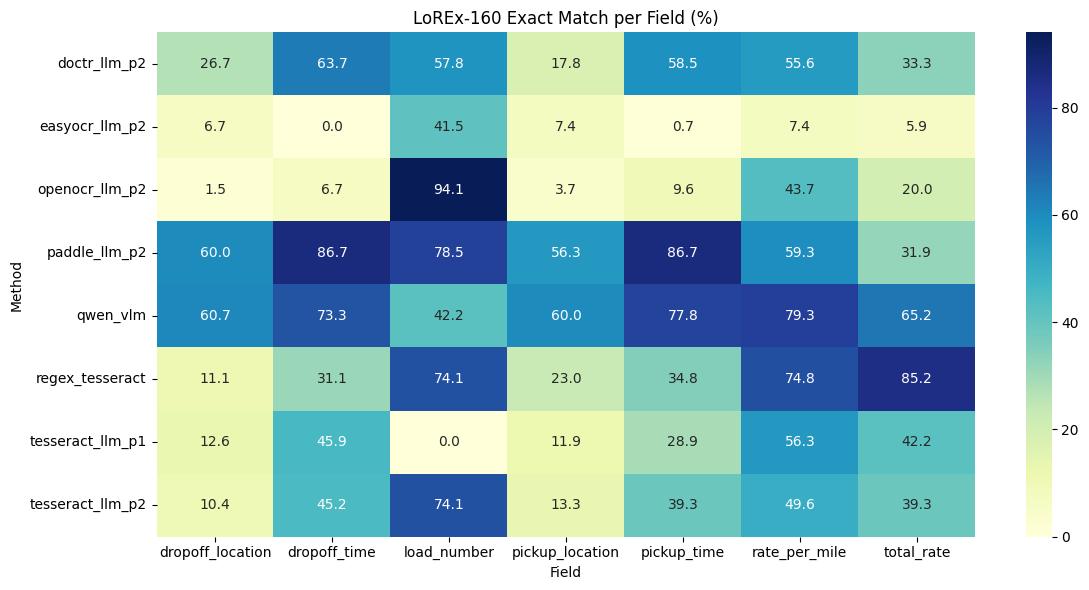

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_exact, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("LoREx-160 Exact Match per Field (%)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

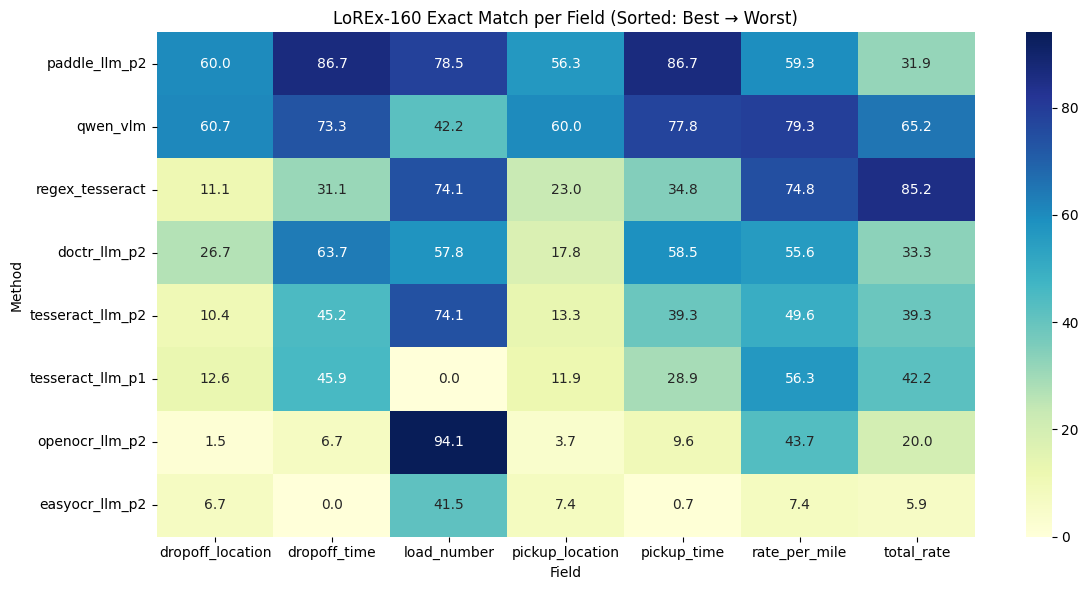

In [44]:
pivot_exact_sorted = pivot_exact.copy()

# add total for sorting only
pivot_exact_sorted["total"] = pivot_exact_sorted.mean(axis=1)

# sort methods
pivot_exact_sorted = pivot_exact_sorted.sort_values("total", ascending=False)

# remove total column from display (optional)
pivot_exact_sorted = pivot_exact_sorted.drop(columns=["total"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_exact_sorted, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("LoREx-160 Exact Match per Field (Sorted: Best → Worst)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

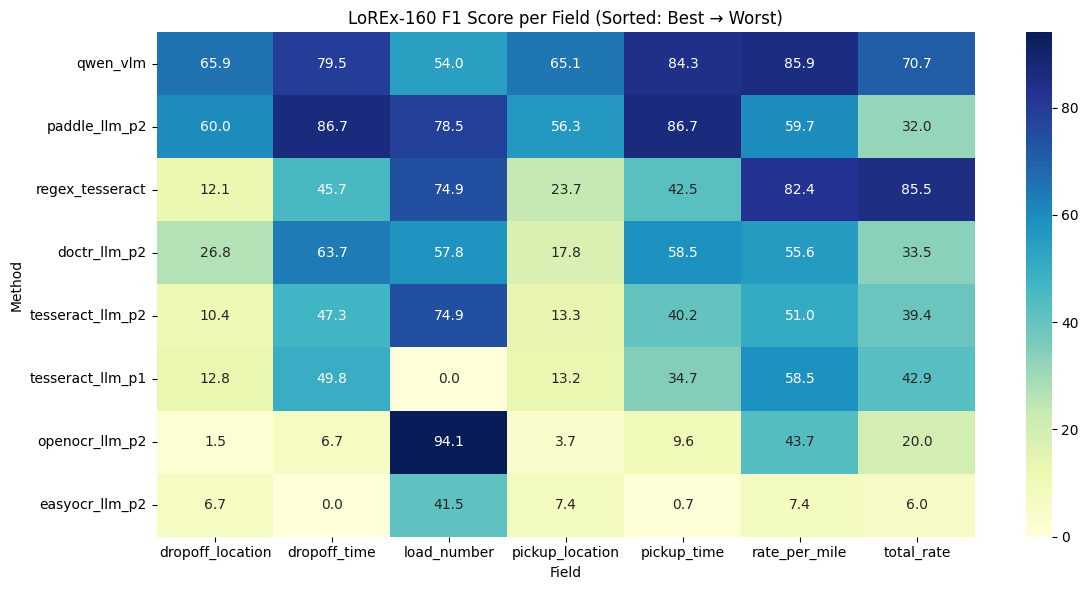

In [57]:
pivot_f1_sorted = pivot_f1.copy()

# add total for sorting
pivot_f1_sorted["total"] = pivot_f1_sorted.mean(axis=1)

# sort methods
pivot_f1_sorted = pivot_f1_sorted.sort_values("total", ascending=False)

# drop total column (optional)
pivot_f1_sorted = pivot_f1_sorted.drop(columns=["total"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1_sorted, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("LoREx-160 F1 Score per Field (Sorted: Best → Worst)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

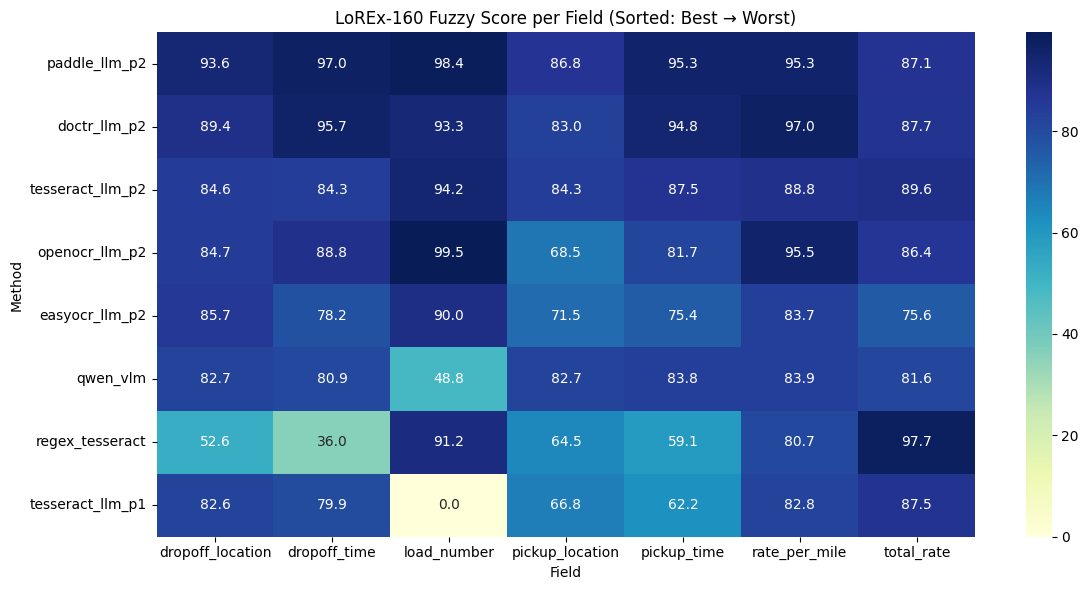

In [58]:
pivot_fuzzy_sorted = pivot_fuzzy.copy()

# add total for sorting
pivot_fuzzy_sorted["total"] = pivot_fuzzy_sorted.mean(axis=1)

# sort methods
pivot_fuzzy_sorted = pivot_fuzzy_sorted.sort_values("total", ascending=False)

# drop total column (optional)
pivot_fuzzy_sorted = pivot_fuzzy_sorted.drop(columns=["total"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_fuzzy_sorted, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("LoREx-160 Fuzzy Score per Field (Sorted: Best → Worst)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

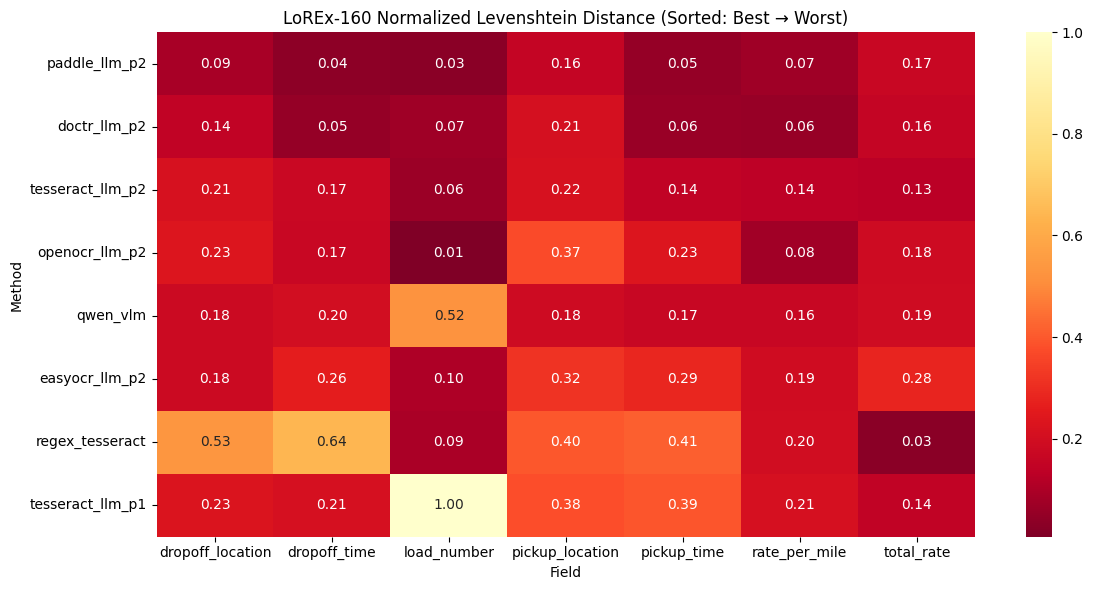

In [59]:
pivot_lev_sorted = pivot_lev.copy()

# add total (average distance)
pivot_lev_sorted["total"] = pivot_lev_sorted.mean(axis=1)

# sort (LOWER is better)
pivot_lev_sorted = pivot_lev_sorted.sort_values("total", ascending=True)

# drop total column (optional)
pivot_lev_sorted = pivot_lev_sorted.drop(columns=["total"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_lev_sorted, annot=True, fmt=".2f", cmap="YlOrRd_r")
plt.title("LoREx-160 Normalized Levenshtein Distance (Sorted: Best → Worst)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

In [51]:
pivot_lev_sim = (1 - pivot_lev) * 100

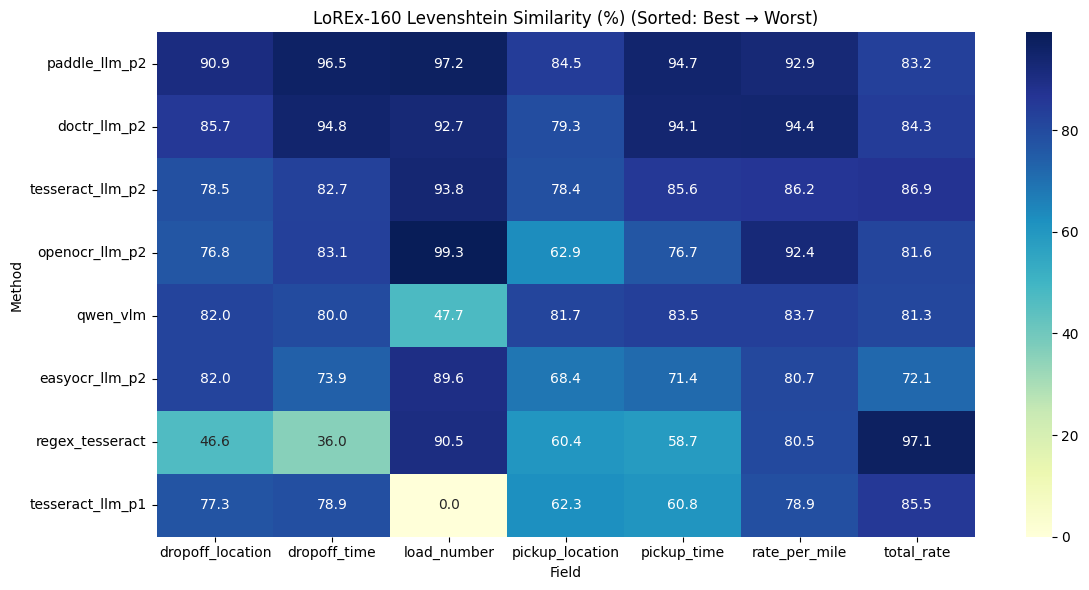

In [60]:
pivot_lev_sorted = pivot_lev_sim.copy()

# add total
pivot_lev_sorted["total"] = pivot_lev_sorted.mean(axis=1)

# now HIGHER is better → sort descending
pivot_lev_sorted = pivot_lev_sorted.sort_values("total", ascending=False)

# drop total
pivot_lev_sorted = pivot_lev_sorted.drop(columns=["total"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_lev_sorted, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("LoREx-160 Levenshtein Similarity (%) (Sorted: Best → Worst)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

In [2]:
# use F1 in %
pivot_f1_pct = pivot_f1 *100

# compute best per column
best_per_field = pivot_f1_pct.max(axis=0)

# gap = best - method
gap = best_per_field - pivot_f1_pct

# sort methods by overall performance (optional but nice)
gap["total"] = gap.mean(axis=1)
gap_sorted = gap.sort_values("total", ascending=True)  # lower gap = better

# drop total column for display
gap_sorted = gap_sorted.drop(columns=["total"])

# plot
plt.figure(figsize=(12, 6))
sns.heatmap(gap_sorted, annot=True, fmt=".1f", cmap="Reds",
            cbar_kws={"label": "Gap (%)"})

plt.title("LoREx-160 Gap to Best Method per Field (F1)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

NameError: name 'pivot_f1' is not defined

<Figure size 1000x600 with 0 Axes>

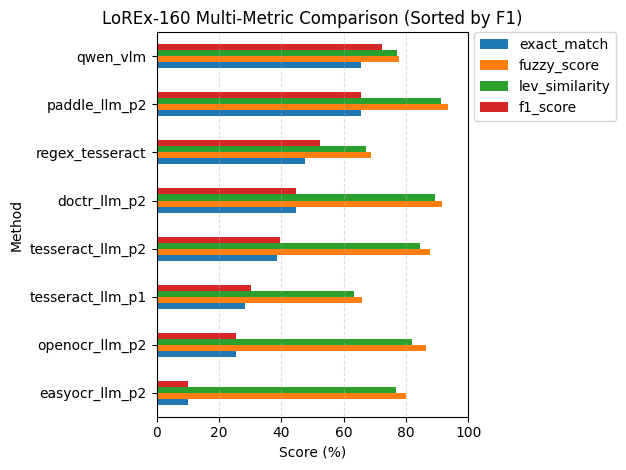

In [ ]:
# compute summary (convert to %)
summary = all_eval.groupby("method")[["exact_match", "fuzzy_score", "levenshtein","f1_score"]].mean()

summary["exact_match"] *= 100
summary["fuzzy_score"] *= 100
summary["f1_score"] *= 100

# convert levenshtein to similarity (%)
summary["lev_similarity"] = (1 - summary["levenshtein"]) * 100

# drop raw levenshtein
summary = summary.drop(columns=["levenshtein"])

# reorder columns (clean + consistent)
summary = summary[["exact_match", "fuzzy_score", "lev_similarity", "f1_score"]]

# sort by F1 (best at top in horizontal plot)
summary = summary.sort_values("f1_score", ascending=True)

# plot
plt.figure(figsize=(10, 6))
summary.plot(kind="barh")

plt.title("LoREx-160 Multi-Metric Comparison (Sorted by F1)")
plt.xlabel("Score (%)")
plt.ylabel("Method")
plt.xlim(0, 100)
plt.legend(loc="lower right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

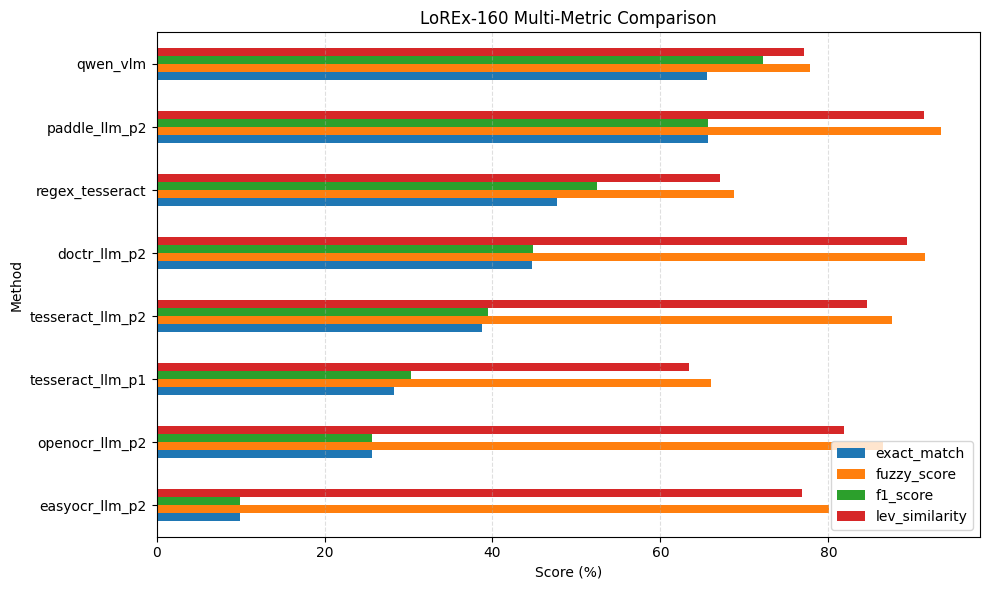

In [64]:
# compute summary (convert to %)
summary = all_eval.groupby("method")[["exact_match", "fuzzy_score", "levenshtein","f1_score"]].mean()

summary["exact_match"] *= 100
summary["fuzzy_score"] *= 100
# convert levenshtein to similarity (%)
summary["lev_similarity"] = (1 - summary["levenshtein"]) * 100

summary["f1_score"] *= 100


# drop raw levenshtein
summary = summary.drop(columns=["levenshtein"])

# sort by F1 (best metric)
summary = summary.sort_values("f1_score", ascending=True)

# plot horizontal bar chart
plt.figure(figsize=(10, 6))

summary.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("LoREx-160 Multi-Metric Comparison")
plt.xlabel("Score (%)")
plt.ylabel("Method")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

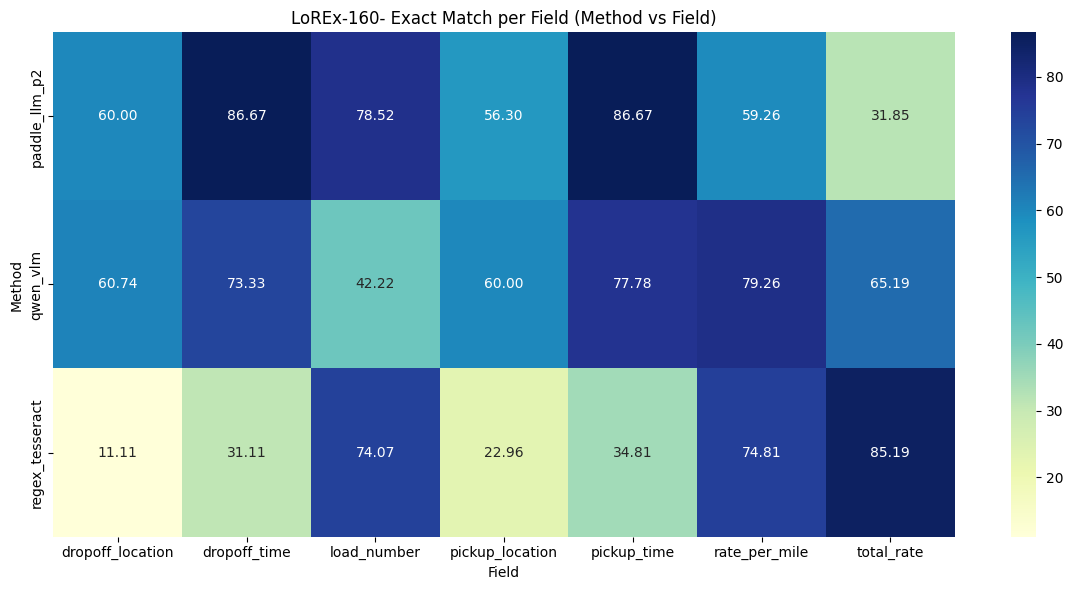

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_exact, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("LoREx-160- Exact Match per Field (Method vs Field)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

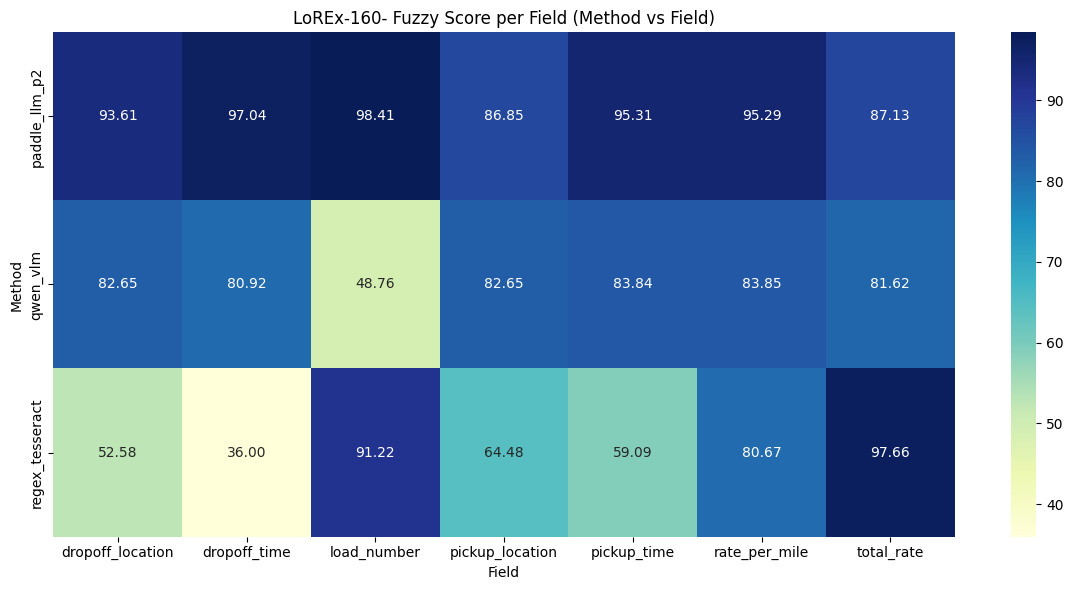

In [19]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_fuzzy*100, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("LoREx-160- Fuzzy Score per Field (Method vs Field)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

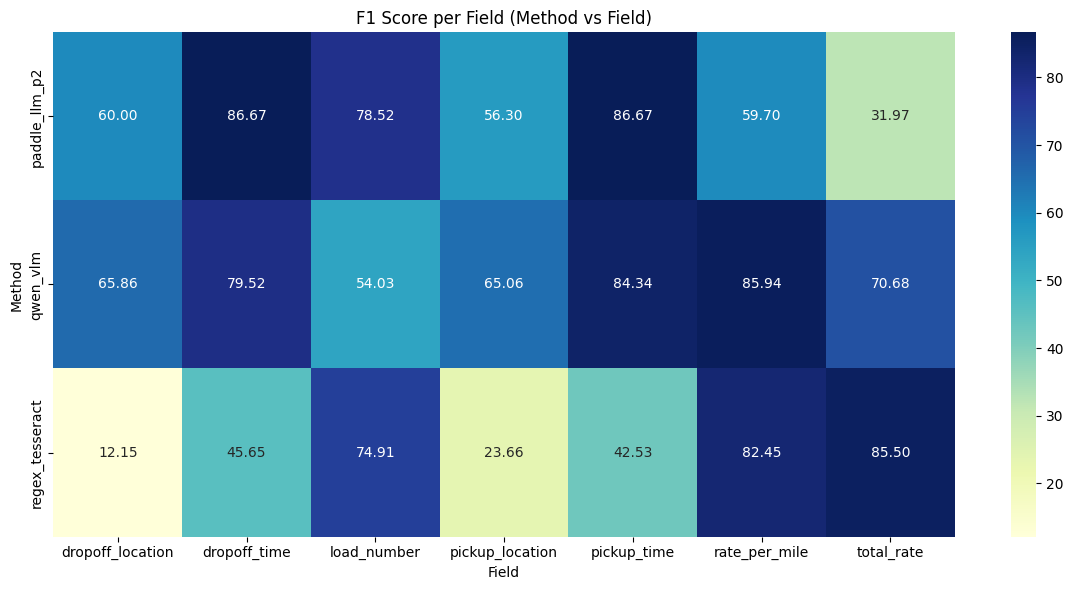

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_f1*100, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("F1 Score per Field (Method vs Field)")
plt.xlabel("Field")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

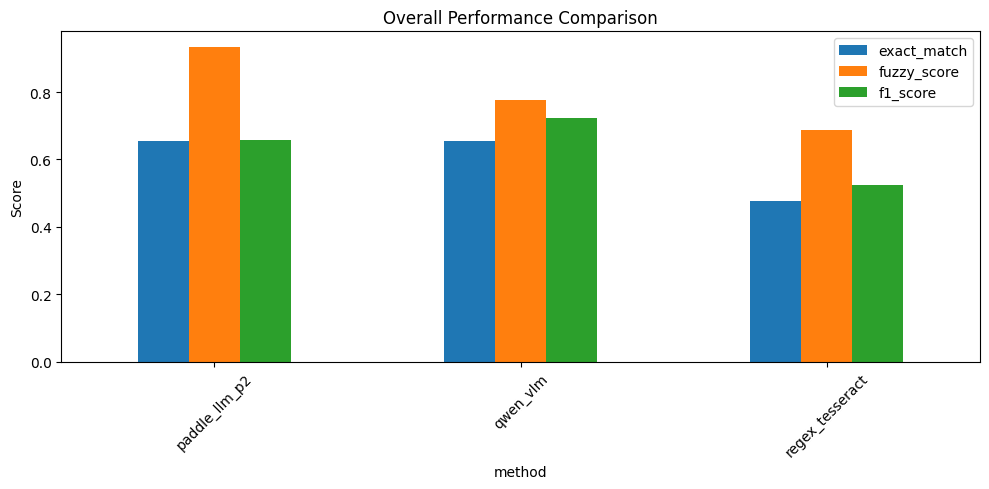

In [22]:
summary = all_eval.groupby("method")[["exact_match", "fuzzy_score", "f1_score"]].mean()

summary.plot(kind="bar", figsize=(10, 5))
plt.title("Overall Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
def compute_gap(pivot_df):
    gap_df = pivot_df.copy()
    gap_df["best"] = gap_df.max(axis=1)
    
    for col in pivot_df.columns:
        gap_df[f"gap_{col}"] = gap_df["best"] - gap_df[col]
    
    return gap_df

gap_f1 = compute_gap(pivot_f1)
gap_f1

field,dropoff_location,dropoff_time,load_number,pickup_location,pickup_time,rate_per_mile,total_rate,best,gap_dropoff_location,gap_dropoff_time,gap_load_number,gap_pickup_location,gap_pickup_time,gap_rate_per_mile,gap_total_rate
method,,,,,,,,,,,,,,,
paddle_llm_p2,0.600000,0.866667,0.785185,0.562963,0.866667,0.597015,0.319703,0.866667,0.266667,0.000000,0.081481,0.303704,0.000000,0.269652,0.546964
qwen_vlm,0.658635,0.795181,0.540284,0.650602,0.843373,0.859438,0.706827,0.859438,0.200803,0.064257,0.319153,0.208835,0.016064,0.000000,0.152610
regex_tesseract,0.121457,0.456522,0.749064,0.236641,0.425339,0.824490,0.855019,0.855019,0.733561,0.398497,0.105955,0.618377,0.429679,0.030529,0.000000


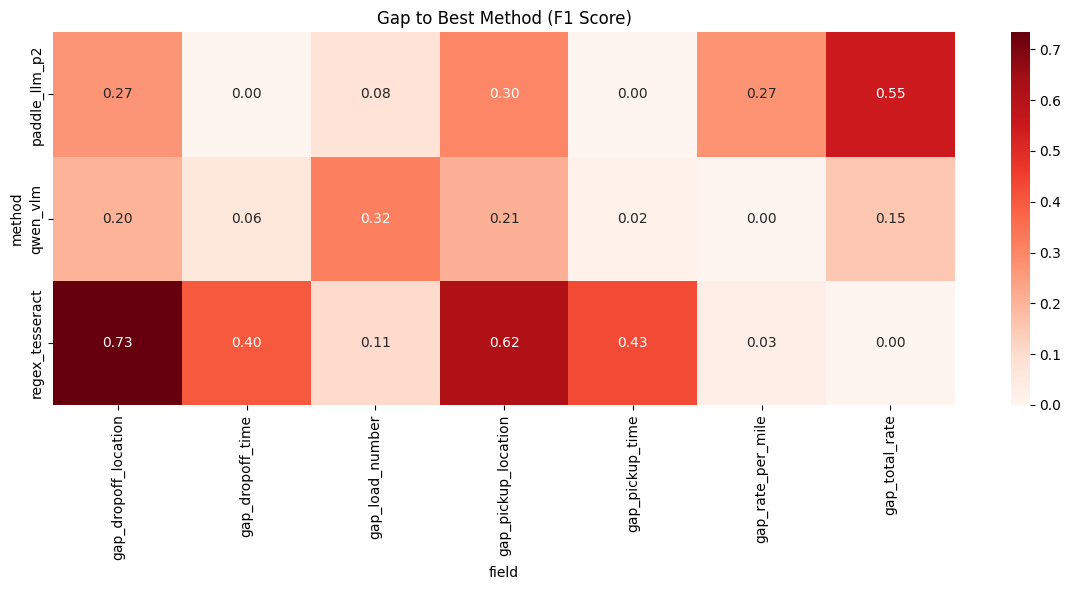

In [31]:
gap_only = gap_f1[[col for col in gap_f1.columns if col.startswith("gap_")]]

plt.figure(figsize=(12, 6))
sns.heatmap(gap_only, annot=True, fmt=".2f", cmap="Reds")
plt.title("Gap to Best Method (F1 Score)")
plt.tight_layout()
plt.show()